# Supplementary Figure 3: MLV Workflow adapted for HSI `.lsm` files acquired with Zeiss LSM-880 Confocal Microscope

**Description:**
This notebook runs the MLV (Section A) workflow adapted from Figure 2 for HSI `.lsm` files acquired with the Confocal Zeiss LSM-880 Microscope.

Sections:

- Import packages and define utility functions for LSM input

- Section a: Multilamellar vesicles (MLVs) analysis and contour plots

It includes helpers to:

- Locate and list `.lsm` files from one or more folders (top-level only, no subfolders).

- Read LSM/TIFF spectral data (`tifffile.imread`) and compute phasor features.

- Normalize harmonic input and build phasor DataFrames for single or multiple harmonics.

- Parse LSM condition labels (DOPC, DPPC, DOPC DPPC + cholesterol %) and sort them consistently.

- Build condition-specific colormaps for contour plots.

- Apply shared axis styling and standardized figure save/show/close behavior.

These functions keep the analysis consistent with Figure 2a for platform comparison.

## 1. Import Dependencies

This section imports all required libraries for loading data, phasor computation, and plotting.

In [24]:
# Core imports for IO, phasor computation, and plotting
import os
import re

import cv2
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tifffile
from matplotlib.patches import Rectangle
from phasorpy.filter import phasor_filter_median, phasor_threshold
from phasorpy.phasor import phasor_from_signal
from phasorpy.plot import PhasorPlot


def list_image_files(data_paths):
    """Return sorted .lsm/.tif/.tiff files in each input folder (non-recursive)."""
    files = []
    for root_path in data_paths:
        if not os.path.exists(root_path):
            continue
        if not os.path.isdir(root_path):
            continue
        for filename in os.listdir(root_path):
            file_path = os.path.join(root_path, filename)
            if not os.path.isfile(file_path):
                continue
            if filename.lower().endswith((".lsm", ".tif", ".tiff")):
                files.append(file_path)
    return sorted(files)


def list_lsm_files(data_paths):
    """Backward-compatible alias for mixed .lsm/.tif/.tiff discovery."""
    return list_image_files(data_paths)


def save_show_close(fig, output_path):
    """Apply layout, display a figure, and close it (no file is saved)."""
    _ = output_path
    plt.tight_layout()
    plt.show()
    plt.close(fig)


def style_axes(ax, tick_size, label_size):
    """Apply shared axis styling used across figures."""
    ax.set_facecolor("white")
    ax.tick_params(axis="both", which="major", labelsize=tick_size)
    ax.set_xlabel(ax.get_xlabel(), fontsize=label_size)
    ax.set_ylabel(ax.get_ylabel(), fontsize=label_size)
    ax.set_title("")


def sort_lipid_condition(condition):
    """Build sorting key for lipid labels and cholesterol percentage."""
    match = re.search(r"(\d+)\s*(?:%|chol\b)", condition, flags=re.IGNORECASE)
    percentage = int(match.group(1)) if match else 0

    if "DOPC DPPC" in condition:
        lipid_priority = 3
    elif "DOPC" in condition:
        lipid_priority = 1
    elif "DPPC" in condition:
        lipid_priority = 2
    else:
        lipid_priority = 4

    return lipid_priority, percentage


def get_group_from_condition(condition):
    """Map a condition string to a lipid group label."""
    if "DOPC DPPC" in condition:
        return "DOPC DPPC"
    if "DOPC" in condition:
        return "DOPC"
    if "DPPC" in condition:
        return "DPPC"
    return "Other"


def get_cholesterol_percentage(condition):
    """Extract cholesterol percentage from a condition string."""
    match = re.search(r"(\d+)\s*(?:%|chol\b)", condition, flags=re.IGNORECASE)
    return int(match.group(1)) if match else 0


def get_condition_colormap(condition):
    """Create a condition-specific colormap and representative color."""
    group = get_group_from_condition(condition)
    chol_pct = get_cholesterol_percentage(condition)

    percentage_to_position = {
        0: 0.45,
        10: 0.55,
        15: 0.62,
        25: 0.70,
        33: 0.78,
        40: 0.85,
        50: 0.95,
    }
    cmap_position = percentage_to_position.get(chol_pct, 0.5)

    base_cmaps = {
        "DOPC": "Blues",
        "DPPC": "Reds",
        "DOPC DPPC": "Greens",
        "Other": "Greys",
    }
    base_cmap = plt.get_cmap(base_cmaps.get(group, "Greys"))

    sampled_color = base_cmap(cmap_position)
    span = np.linspace(cmap_position - 0.1, cmap_position + 0.1, 256)
    span = np.clip(span, 0.0, 1.0)
    colors_list = [base_cmap(v) for v in span]
    custom_cmap = mcolors.LinearSegmentedColormap.from_list(
        f"{group}_{chol_pct}", colors_list
    )
    return custom_cmap, sampled_color


def normalize_harmonics(harmonics):
    """Normalize harmonic input into a list."""
    if harmonics is None:
        return [1]
    if isinstance(harmonics, int):
        return [harmonics]
    return harmonics


def _split_harmonics(real, imag, harmonics):
    """Return lists of harmonic arrays independent of phasor output shape."""
    if len(harmonics) == 1:
        return [np.asarray(real)], [np.asarray(imag)]

    real_array = np.asarray(real)
    imag_array = np.asarray(imag)

    if real_array.shape[0] == len(harmonics):
        real_harmonics = [real_array[i] for i in range(len(harmonics))]
        imag_harmonics = [imag_array[i] for i in range(len(harmonics))]
    elif real_array.shape[-1] == len(harmonics):
        real_harmonics = [
            np.take(real_array, i, axis=-1) for i in range(len(harmonics))
        ]
        imag_harmonics = [
            np.take(imag_array, i, axis=-1) for i in range(len(harmonics))
        ]
    else:
        raise ValueError(
            f"Unexpected harmonic shape: real={real_array.shape}, imag={imag_array.shape}"
        )

    return real_harmonics, imag_harmonics


def resolve_mask_paths(data_paths, mask_paths=None):
    """Resolve mask roots, defaulting each data path to a `mask` subfolder."""
    if not data_paths:
        return None

    if mask_paths is None:
        return [os.path.join(data_root, "mask") for data_root in data_paths]

    if len(data_paths) != len(mask_paths):
        raise ValueError("data_paths and mask_paths must have the same length.")

    return mask_paths


def extract_lsm_condition(filename):
    """Parse LSM filename into normalized condition labels used for plotting."""
    # Convert names like 'DOPC 25 Chol_3' -> 'DOPC 25%'.
    base = re.sub(r"_\d+$", "", filename).strip()
    base = re.sub(r"(\d+)\s*chol\b", r"\1%", base, flags=re.IGNORECASE)
    base = re.sub(r"\s+", " ", base).strip()
    return base


def get_mask_file_for_lsm(file_path, data_paths, mask_paths):
    """Return matching mask path for an LSM file using aligned data/mask roots.

    Supports two mask directory structures:
    1. Root mask folder (e.g., <data_path>/mask/mask_<filename>.png)
    2. Local mask folder at same level as LSM (e.g., <lsm_dir>/mask/mask_<filename>.png)
    """
    if not data_paths or not mask_paths:
        return None

    file_abs = os.path.abspath(file_path)
    file_dir = os.path.dirname(file_abs)
    base_filename = os.path.splitext(os.path.basename(file_path))[0]

    # First, try local mask folder at same level as LSM file.
    local_mask_folder = os.path.join(file_dir, "mask")
    local_candidate = os.path.join(local_mask_folder, f"mask_{base_filename}.png")
    if os.path.isfile(local_candidate):
        return local_candidate

    # Fall back to root mask folder specified in mask_paths.
    for data_root, mask_root in zip(data_paths, mask_paths):
        data_root_abs = os.path.abspath(data_root)
        try:
            is_under_root = (
                os.path.commonpath([file_abs, data_root_abs]) == data_root_abs
            )
        except ValueError:
            is_under_root = False

        if not is_under_root:
            continue

        relative_dir = os.path.relpath(os.path.dirname(file_path), data_root_abs)

        candidates = []
        if relative_dir != ".":
            candidates.append(
                os.path.join(mask_root, relative_dir, f"mask_{base_filename}.png")
            )
        candidates.append(os.path.join(mask_root, f"mask_{base_filename}.png"))

        for candidate in candidates:
            if os.path.isfile(candidate):
                return candidate

    return None


def load_mask_for_lsm(file_path, data_paths, mask_paths, target_shape):
    """Load a PNG mask for an LSM file and adapt size to target array shape."""
    if target_shape is None or len(target_shape) < 2:
        return None

    mask_file = get_mask_file_for_lsm(file_path, data_paths, mask_paths)
    if mask_file is None:
        return None

    mask_img = cv2.imread(mask_file, cv2.IMREAD_GRAYSCALE)
    if mask_img is None:
        return None

    target_hw = (target_shape[0], target_shape[1])
    if mask_img.shape != target_hw:
        mask_img = cv2.resize(
            mask_img, (target_hw[1], target_hw[0]), interpolation=cv2.INTER_NEAREST
        )

    return mask_img > 0


def apply_mask_to_arrays(mean, real, imag, mask):
    """Apply mask to phasor arrays, setting masked values to NaN."""
    if mask is None:
        return mean, real, imag

    keep_mask = mask.astype(bool)

    mean_masked = np.asarray(mean).copy()
    mean_masked[~keep_mask] = np.nan

    def _mask_value(value):
        value_masked = np.asarray(value).copy()
        value_masked[~keep_mask] = np.nan
        return value_masked

    if isinstance(real, list):
        real_masked = [_mask_value(r) for r in real]
    else:
        real_masked = _mask_value(real)

    if isinstance(imag, list):
        imag_masked = [_mask_value(i) for i in imag]
    else:
        imag_masked = _mask_value(imag)

    return mean_masked, real_masked, imag_masked


def get_phasor_dataframe_from_lsm(
    lsm_file_list,
    condition_extractor=None,
    harmonics=None,
    axis=0,
    mean_min=3,
    data_paths=None,
    mask_paths=None,
):
    """Compute phasor features from .lsm/.tif files and return a tidy DataFrame."""
    harmonics = normalize_harmonics(harmonics)
    resolved_mask_paths = resolve_mask_paths(data_paths, mask_paths)

    mean_data = []
    real_data = {h: [] for h in harmonics}
    imag_data = {h: [] for h in harmonics}
    condition_labels = []

    for file_path in lsm_file_list:
        filename = os.path.splitext(os.path.basename(file_path))[0]
        condition = condition_extractor(filename) if condition_extractor else filename

        signal = tifffile.imread(file_path)
        if len(harmonics) == 1:
            mean, real, imag = phasor_from_signal(
                signal, harmonic=harmonics[0], axis=axis
            )
        else:
            mean, real, imag = phasor_from_signal(signal, harmonic=harmonics, axis=axis)

        mean, real, imag = phasor_filter_median(mean, real, imag, size=3, repeat=3)
        mean, real, imag = phasor_threshold(mean, real, imag, mean_min=mean_min)

        real_harmonics, imag_harmonics = _split_harmonics(real, imag, harmonics)

        mask = load_mask_for_lsm(
            file_path,
            data_paths,
            resolved_mask_paths,
            target_shape=np.asarray(mean).shape,
        )
        mean, real_harmonics, imag_harmonics = apply_mask_to_arrays(
            mean, real_harmonics, imag_harmonics, mask
        )

        mean_flat = np.asarray(mean).flatten()
        real_flat = [np.asarray(r).flatten() for r in real_harmonics]
        imag_flat = [np.asarray(i).flatten() for i in imag_harmonics]

        valid_mask = np.isfinite(mean_flat)
        for harmonic_index in range(len(harmonics)):
            valid_mask &= np.isfinite(real_flat[harmonic_index])
            valid_mask &= np.isfinite(imag_flat[harmonic_index])

        mean_clean = mean_flat[valid_mask]
        if len(mean_clean) == 0:
            continue

        mean_data.extend(mean_clean)
        condition_labels.extend([condition] * len(mean_clean))
        for harmonic_index, harmonic in enumerate(harmonics):
            real_data[harmonic].extend(real_flat[harmonic_index][valid_mask])
            imag_data[harmonic].extend(imag_flat[harmonic_index][valid_mask])

    result = {
        "Mean": mean_data,
        "Condition": condition_labels,
    }

    if len(harmonics) == 1:
        result["Real"] = real_data[harmonics[0]]
        result["Imag"] = imag_data[harmonics[0]]
    else:
        for harmonic in harmonics:
            result[f"Real_h{harmonic}"] = real_data[harmonic]
            result[f"Imag_h{harmonic}"] = imag_data[harmonic]

    return pd.DataFrame(result)

## Multilamellar Vesicles (MLV) analysis of LAURDAN fluorescence 

### MLV Input Loading and Global Contours (LSM-880)
Load MLV `.lsm` and `.tif` files, compute harmonic phasor data, and generate the merged phasor contour plot with a zoom rectangle.

### Key parameters
- `data_paths`: input folders for MLV `.lsm`/`.tif` datasets.
- `mask_paths`: optional mask folders aligned with `data_paths`; set `None` to use `<data_path>/mask` by default.
- `output_folder_a`: where figures are saved.
- `harmonics` in `get_phasor_dataframe_from_lsm` (currently `[1, 2]`).
- `zoom_xlim_a`, `zoom_ylim_a`: zoom window limits.
- Contour style arguments (`linewidths`, `levels`, `alpha`) for merged contours.
- Figure size and axis text sizes in `plt.subplots` and `style_axes`.

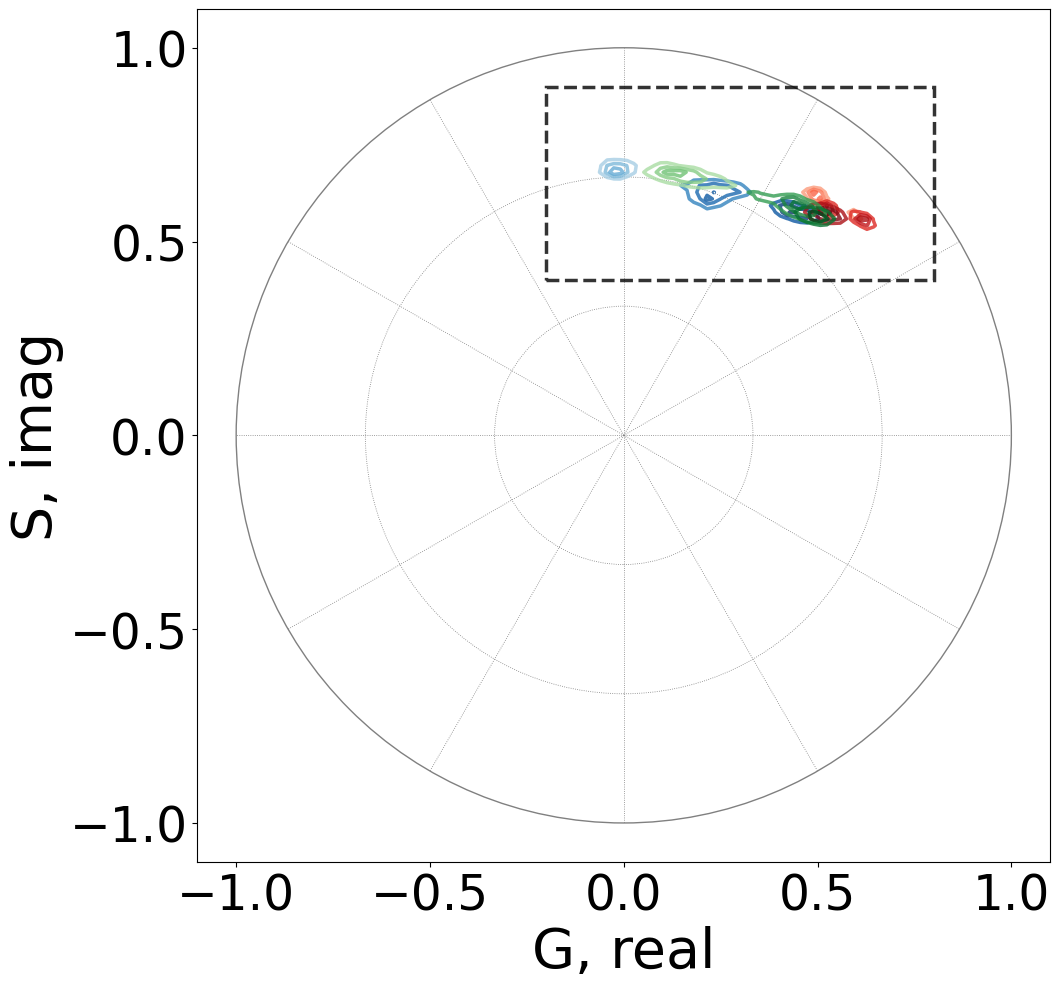

In [25]:
# Load and merge all MLV .lsm/.tif files before plotting condition contours.
data_paths = [
    "/Users/bruno/Documents/UBA/phSFC/phSFC_analisis/Datos/Micro confocal 880/2026-02-12 Liposomas copy",
    '/Users/bruno/Documents/UBA/phSFC/phSFC_analisis/Datos/Micro confocal 880/2025-07-16 liposomas laurdan colesterol',
]

# Optional override for masks. If None, default is <data_path>/mask for each entry.
mask_paths = None

output_folder_a = os.path.join("Supp_Figure_3", "Figure_3a")
os.makedirs(output_folder_a, exist_ok=True)

image_files_a = list_image_files(data_paths)
mlvs_phasor_dataframe = get_phasor_dataframe_from_lsm(
    image_files_a,
    condition_extractor=extract_lsm_condition,
    harmonics=[1],
    axis=0,
    mean_min=5,
    data_paths=data_paths,
    mask_paths=mask_paths,
)
unique_conditions_a = sorted(
    mlvs_phasor_dataframe["Condition"].unique(), key=sort_lipid_condition
)

# Support both single-harmonic (Real/Imag) and multi-harmonic (Real_h1/Imag_h1) tables.
real_col = "Real_h1" if "Real_h1" in mlvs_phasor_dataframe.columns else "Real"
imag_col = "Imag_h1" if "Imag_h1" in mlvs_phasor_dataframe.columns else "Imag"

# Match zoom limits used in statistics_phasor_plot_liposomas_880.py
zoom_xlim_a = (-0.2, 0.8)
zoom_ylim_a = (0.4, 0.9)

fig, ax = plt.subplots(figsize=(12, 10), facecolor="white")
style_axes(ax, tick_size=35, label_size=40)
phasor_plot = PhasorPlot(allquadrants=True, title="", ax=ax)

for condition in unique_conditions_a:
    condition_data = mlvs_phasor_dataframe[
        mlvs_phasor_dataframe["Condition"] == condition
    ]

    if len(condition_data) <= 10:
        continue

    real = condition_data[real_col].values
    imag = condition_data[imag_col].values
    custom_cmap, _ = get_condition_colormap(condition)
    phasor_plot.contour(
        real, imag, cmap=custom_cmap, linewidths=2.5, levels=3, alpha=0.8
    )

# Draw the rectangle that defines the region shown in the dedicated zoom panel.
zoom_rect = Rectangle(
    (zoom_xlim_a[0], zoom_ylim_a[0]),
    zoom_xlim_a[1] - zoom_xlim_a[0],
    zoom_ylim_a[1] - zoom_ylim_a[0],
    linewidth=2.5,
    edgecolor="black",
    facecolor="none",
    linestyle="--",
    alpha=0.8,
    zorder=10,
)
ax.add_patch(zoom_rect)

handles, labels = ax.get_legend_handles_labels()
if handles:
    ax.legend(handles, labels, bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=8)

save_show_close(
    fig,
    os.path.join(output_folder_a, "phasor_contour_all_conditions_merged.png"),
)

### Zoomed MLV View
Create the zoomed MLV phasor contour view using the same condition coloring and harmonic projections.

### Key parameters
- `zoom_xlim_a`, `zoom_ylim_a`: displayed phasor range in the zoom panel.
- Contour appearance (`linewidths`, `levels`, `alpha`).
- Tick spacing in `ax.set_xticks` and `ax.set_yticks`.
- Output filename for the zoomed figure.

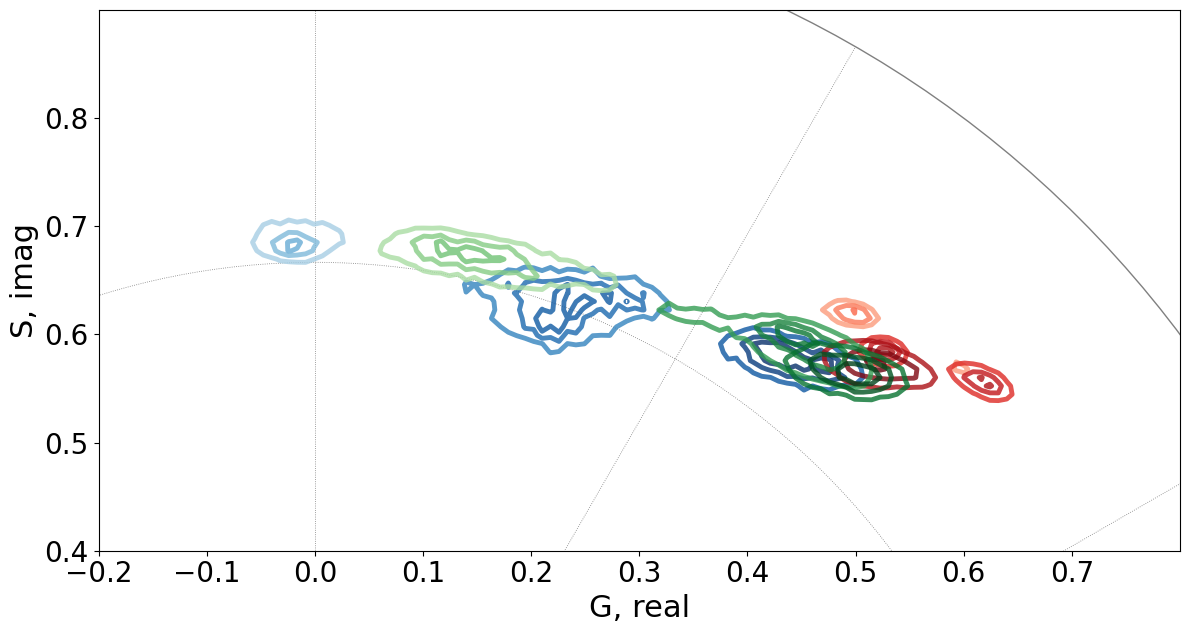

In [26]:
# Zoomed phasor plot section
fig, ax = plt.subplots(figsize=(12, 10), facecolor="white")
style_axes(ax, tick_size=20, label_size=22)
phasor_plot_zoom = PhasorPlot(
    allquadrants=True, title="", ax=ax, xlim=zoom_xlim_a, ylim=zoom_ylim_a
)

# Reuse the same condition loop, but restrict rendering to the zoomed window.
for condition in unique_conditions_a:
    condition_data = mlvs_phasor_dataframe[
        mlvs_phasor_dataframe["Condition"] == condition
    ]
    if len(condition_data) <= 10:
        continue

    real = condition_data[real_col].values
    imag = condition_data[imag_col].values
    custom_cmap, _ = get_condition_colormap(condition)
    phasor_plot_zoom.contour(
        real, imag, cmap=custom_cmap, linewidths=3.5, levels=3, alpha=0.8
    )

# Match zoom ticks used in statistics_phasor_plot_liposomas_880.py
ax.set_xticks(np.arange(-0.2, 0.8, 0.1))
ax.set_yticks(np.arange(0.4, 0.9, 0.1))

save_show_close(
    fig,
    os.path.join(output_folder_a, "phasor_contour_all_conditions_merged_zoom.png"),
)